In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import seaborn as sns
from scipy import stats
import pyvinecopulib as pv
from scipy.interpolate import interp1d
%matplotlib inline

from py_banshee.copula_test import cvm_statistic
from py_banshee.rankcorr import bn_rankcorr

import functions as fn
import model_functions as mf
from get_matrices import get_matrices
%load_ext autoreload
%autoreload 2

import networkx as nx



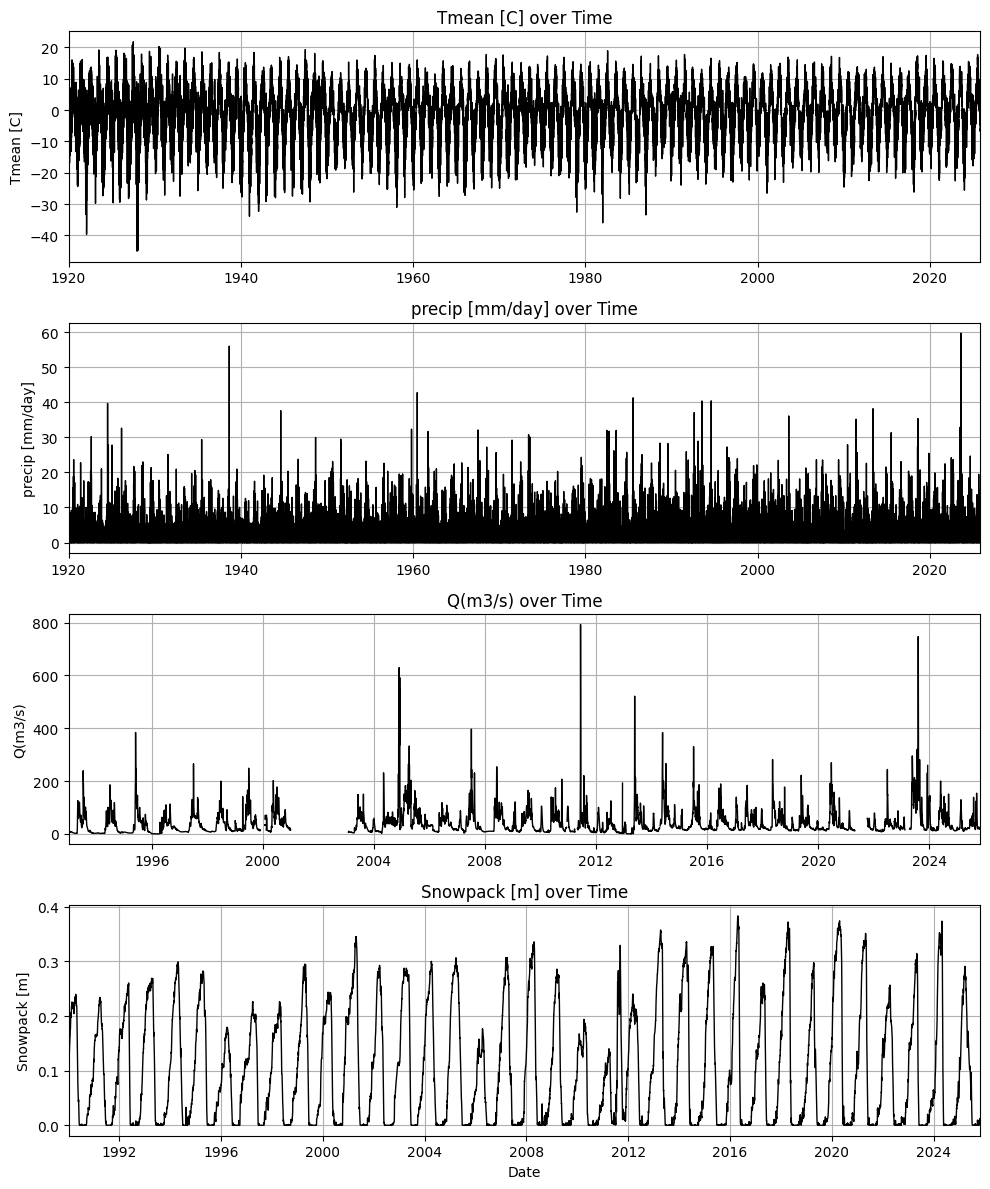

In [ ]:
df = fn.import_data("..\\Data\\processed_data.csv")
fn.plot_all(df, dropna=False)
# df.dropna(inplace=True)



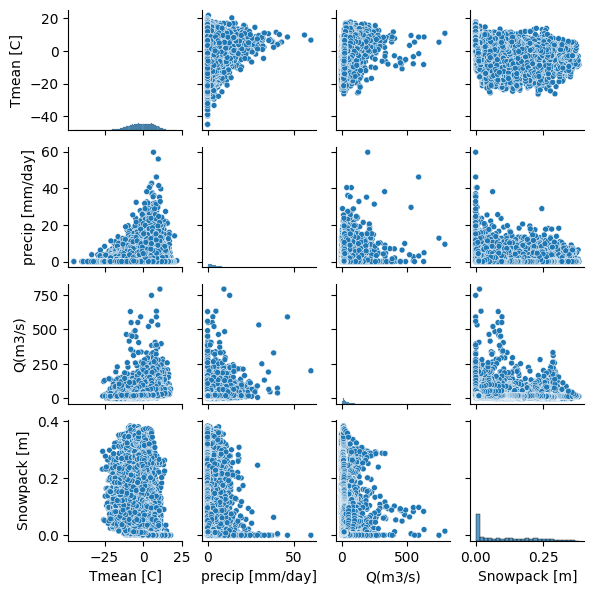

In [4]:
sns.pairplot(df, height=1.5,plot_kws=dict(size=.1))

Precip and Snowpack both have many repeated values, which are probably zero, they are assigned the same rank.
after scaling to [0,1], this produces many points with the same u-value, which appear as horizontal or verical lines. 
The vertical stripes indicate many tied observations in the original variables, (zero precipitation)
Dependence the copula is meant to model. 

In [5]:
data = df[["Q(m3/s)"]].copy()
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

df_max_Q = pd.DataFrame()

df_max_Q['exces'] = exces
df_max_Q['date'] = dpeak


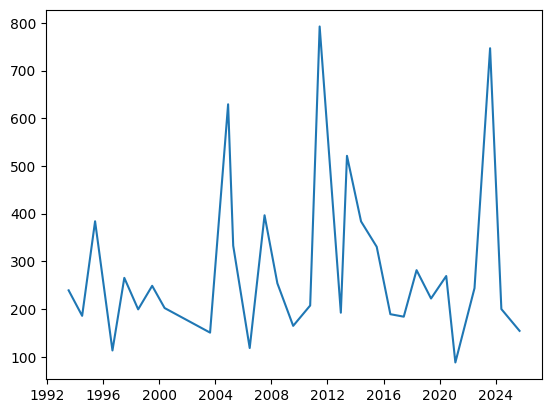

In [6]:
df['Year'] = df.index.year
df['Month'] = df.index.month

idx_max = (
    df.groupby(['Year'])['Q(m3/s)']
      .idxmax()
      .dropna()
)

max_list = df.loc[idx_max]
# display(max_list)
plt.plot(max_list.index, max_list['Q(m3/s)'])

In [7]:
data_snow = pd.DataFrame()
data_snow = df[["Snowpack [m]", "Year", "Month"]].copy()

data_snow = data_snow[data_snow["Snowpack [m]"] > 0]
data_snow = data_snow.dropna()

display(data_snow.head(10))
# display(data_snow)

## calculate snowpack over month ~sum
monthly_sum_snow = data_snow.groupby(['Year', 'Month'])['Snowpack [m]'].sum()
# print(monthly_sum_snow)

# print(monthly_sum_snow.loc[(1992, 11):(1992, 12)])

winter_snowpack1990 = monthly_sum_snow.loc[1990][0:3]
print(winter_snowpack1990)

,Snowpack [m],Year,Month
date,,,
1990-01-01,0.107858,1990,1
1990-01-02,0.108081,1990,1
1990-01-03,0.108451,1990,1
1990-01-04,0.109092,1990,1
1990-01-05,0.108881,1990,1
1990-01-06,0.109582,1990,1
1990-01-07,0.112527,1990,1
1990-01-08,0.113377,1990,1
1990-01-09,0.115163,1990,1


Month
1    4.430062
2    5.936291
3    6.745495
Name: Snowpack [m], dtype: float64


In [8]:
winter_snowpack = {}
for year in range(1993, 2026):
    winter_snowpack[year] = np.sum(monthly_sum_snow.loc[year][0:3]) + np.sum(monthly_sum_snow.loc[year-1][10:11])
    #print(f"Winter snowpack for year {year}:")
    #print(winter_snowpack[year])
for y in [2001, 2002]:
    winter_snowpack.pop(y, None)

The spearman correlation coefficient for winter snowpack (Nov) is: 0.2556451612903226
The correlation coefficient for winter snowpack (Nov) is: 0.21043733706208131
The spearman correlation coefficient for winter snowpack (Dec) is: -0.010898088293170863
The correlation coefficient for winter snowpack (Dec) is: -0.24353223167909477
The spearman correlation coefficient for winter snowpack (Jan) is: 0.4161290322580646
The correlation coefficient for winter snowpack (Jan) is: 0.11334543947464729
The spearman correlation coefficient for winter snowpack (Feb) is: 0.31935483870967746
The correlation coefficient for winter snowpack (Feb) is: -0.02383354998509518
The strongest pearson correlation is for month: Nov with value: 0.21043733706208131
The strongest spearman correlation is for month: Jan with value: 0.4161290322580646


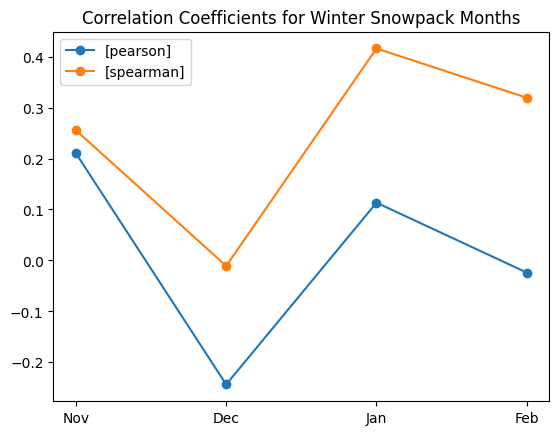

In [9]:
#calculate strongest correlation for each month in winter for each extreme event 
months_info = {
    'Nov': (-1, 10, 11),  # year offset, start month idx, end month idx (exclusive)
    'Dec': (-1, 11, 12),
    'Jan': (0, 0, 1),
    'Feb': (0, 1, 2)
}

rhos = []
spearman = []

for m, (y_off, start_idx, end_idx) in months_info.items():
    snowpack = {}

    for year in range(1993, 2026):
        if year in [2001, 2002]:
            continue

        values = monthly_sum_snow.loc[year + y_off][start_idx:end_idx]

        snowpack[year] = np.sum(values)  

    rho = stats.pearsonr(max_list['Q(m3/s)'], list(snowpack.values()))[0]
    rhos.append(rho)
    spearman_rho = stats.spearmanr(max_list['Q(m3/s)'], list(snowpack.values()))[0]
    spearman.append(spearman_rho)
    print(f'The spearman correlation coefficient for winter snowpack ({m}) is:', spearman_rho)

    print(f'The correlation coefficient for winter snowpack ({m}) is:', rho)

plt.plot(list(months_info.keys()), rhos, marker='o', label = '[pearson]')
plt.plot(list(months_info.keys()), spearman, marker='o', label = '[spearman]')
plt.title('Correlation Coefficients for Winter Snowpack Months')
plt.legend()

print('The strongest pearson correlation is for month:', list(months_info.keys())[np.argmax(rhos)], 'with value:', np.max(rhos))
print('The strongest spearman correlation is for month:', list(months_info.keys())[np.argmax(spearman)], 'with value:', np.max(spearman))

The strongest correlation is for 3 months cummulative snowpack with spearman rho = 0.32620967741935486


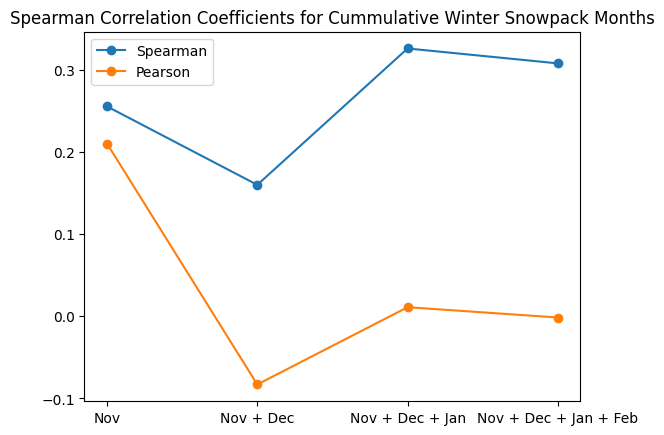

In [10]:
#calculate each cummulative month correlation
winter_snowpack_1month = {}
for year in range(1993, 2026):
    winter_snowpack_1month[year] = np.sum(monthly_sum_snow.loc[year-1][10:11])
for y in [2001, 2002]:
    winter_snowpack_1month.pop(y, None)

rho_snow_1month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_1month.values()))
spearman_rho_1month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_1month.values()))


winter_snowpack_2month = {}
for year in range(1993, 2026):
    winter_snowpack_2month[year] =np.sum(monthly_sum_snow.loc[year-1][10:12])
for y in [2001, 2002]:
    winter_snowpack_2month.pop(y, None)
rho_snow_2month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_2month.values()))
spearman_rho_2month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_2month.values()))


winter_snowpack_3month = {}
for year in range(1993, 2026):
    winter_snowpack_3month[year] = np.sum(monthly_sum_snow.loc[year-1][10:12]) + np.sum(monthly_sum_snow.loc[year][0:1])
for y in [2001, 2002]:
    winter_snowpack_3month.pop(y, None)
rho_snow_3month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_3month.values()))
spearman_rho_3month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_3month.values()))


winter_snowpack_4month = {}
for year in range(1993, 2026):
    winter_snowpack_4month[year] = np.sum(monthly_sum_snow.loc[year][0:2])  +  np.sum(monthly_sum_snow.loc[year-1][10:12])
for y in [2001, 2002]:
    winter_snowpack_4month.pop(y, None)
rho_snow_4month = stats.pearsonr(max_list['Q(m3/s)'], list(winter_snowpack_4month.values()))
spearman_rho_4month = stats.spearmanr(max_list['Q(m3/s)'], list(winter_snowpack_4month.values()))

months = ['Nov', 'Nov + Dec', 'Nov + Dec + Jan', 'Nov + Dec + Jan + Feb']
spearman_months = [spearman_rho_1month[0], spearman_rho_2month[0], spearman_rho_3month[0], spearman_rho_4month[0]]
pearson_months = [rho_snow_1month[0], rho_snow_2month[0], rho_snow_3month[0], rho_snow_4month[0]]

plt.plot(months, spearman_months, marker='o', label='Spearman')
plt.plot(months, pearson_months, marker='o', label='Pearson')
plt.title('Spearman Correlation Coefficients for Cummulative Winter Snowpack Months')
plt.legend()

print('The strongest correlation is for 3 months cummulative snowpack with spearman rho =', spearman_rho_3month[0])

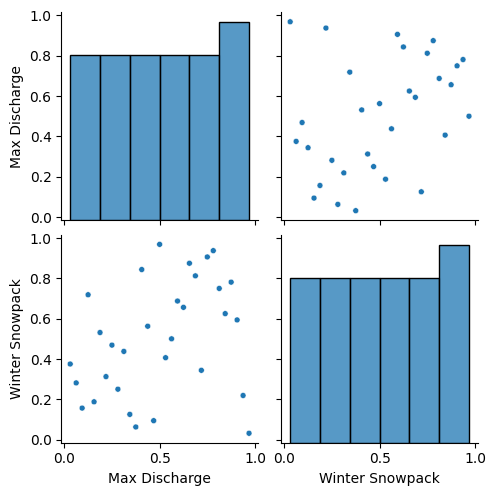

In [11]:
def unity(data):
    u_hat = pd.DataFrame()
    n = len(data)
    for col in data.columns:
        u_hat[col]= stats.rankdata(data[col]) / (n + 1)
    return u_hat

def sd_normal(data):
    sd_normal_df = data.copy()
    for col in data.columns:
        sd_normal_df[col] = stats.norm.ppf(data[col])
    return sd_normal_df

unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Winter Snowpack': list(winter_snowpack_3month.values())}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

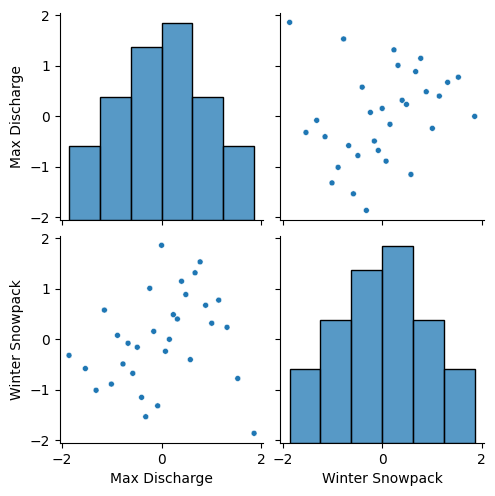

In [12]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [13]:
precip1993 = np.sum(df['precip [mm/day]'].loc['1993-07-06':'1993-07-13'])
print(precip1993)

precip1994 = np.sum(df['precip [mm/day]'].loc['1994-06-24':'1994-06-30'])
print(precip1994)

precip1995 = np.sum(df['precip [mm/day]'].loc['1995-05-25':'1995-06-02'])
print(precip1995)

precip1996 = np.sum(df['precip [mm/day]'].loc['1996-08-21':'1996-08-28'])
print(precip1996)

precip1997 = np.sum(df['precip [mm/day]'].loc['1997-06-26':'1997-07-03'])
print(precip1997)

precip1998 = np.sum(df['precip [mm/day]'].loc['1998-06-22':'1998-06-29'])



70.025462
29.106485999999997
58.782087000000004
58.2748063
54.2982945


In [14]:
#calculate precip over 5 days prior to peak discharge
precip = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):

    precip[i] = df.loc[date - pd.Timedelta(days=5):date, 'precip [mm/day]'].sum()

        
# print(precip)


The correlation coefficient for 1-day precipitation is: 0.46480910056474184
The spearman correlation coefficient for 1-day precipitation is: 0.12948770718714187
The correlation coefficient for 2-day precipitation is: 0.6334502593624386
The spearman correlation coefficient for 2-day precipitation is: 0.2544611364882503
The correlation coefficient for 3-day precipitation is: 0.6051832525394204
The spearman correlation coefficient for 3-day precipitation is: 0.23591087931161087
The correlation coefficient for 4-day precipitation is: 0.5687436144528442
The spearman correlation coefficient for 4-day precipitation is: 0.19639076619616153
The correlation coefficient for 5-day precipitation is: 0.5521407797446556
The spearman correlation coefficient for 5-day precipitation is: 0.20445609540339607
The correlation coefficient for 6-day precipitation is: 0.5499225370938644
The spearman correlation coefficient for 6-day precipitation is: 0.22703901718365282
The correlation coefficient for 7-day pr

Text(0, 0.5, 'Correlation coefficient')

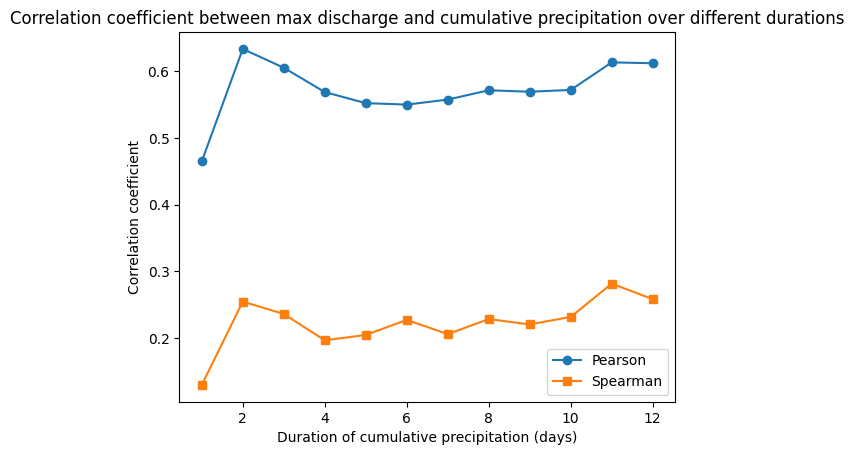

In [15]:
#find strongest relation for cummulative precip over 1 to 10 days prior to peak discharge
precip1d = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):
    precip1d[i] = df.loc[date - pd.Timedelta(days=1):date, 'precip [mm/day]'].sum()

rho_1 = stats.pearsonr(max_list['Q(m3/s)'], precip1d)
print('The correlation coefficient for 1-day precipitation is:', rho_1[0])
spearman_1 = stats.spearmanr(max_list['Q(m3/s)'], precip1d)
print('The spearman correlation coefficient for 1-day precipitation is:', spearman_1[0])

precip2d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip2d[i] = df.loc[date - pd.Timedelta(days=2):date, 'precip [mm/day]'].sum()
rho_2 = stats.pearsonr(max_list['Q(m3/s)'], precip2d)
print('The correlation coefficient for 2-day precipitation is:', rho_2[0])
spearman_2 = stats.spearmanr(max_list['Q(m3/s)'], precip2d)
print('The spearman correlation coefficient for 2-day precipitation is:', spearman_2[0])

precip3d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip3d[i] = df.loc[date - pd.Timedelta(days=3):date, 'precip [mm/day]'].sum() 
rho_3 = stats.pearsonr(max_list['Q(m3/s)'], precip3d)
print('The correlation coefficient for 3-day precipitation is:', rho_3[0])
spearman_3 = stats.spearmanr(max_list['Q(m3/s)'], precip3d)
print('The spearman correlation coefficient for 3-day precipitation is:', spearman_3[0])

precip4d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip4d[i] = df.loc[date - pd.Timedelta(days=4):date, 'precip [mm/day]'].sum() 
rho_4 = stats.pearsonr(max_list['Q(m3/s)'], precip4d)
print('The correlation coefficient for 4-day precipitation is:', rho_4[0])
spearman_4 = stats.spearmanr(max_list['Q(m3/s)'], precip4d)
print('The spearman correlation coefficient for 4-day precipitation is:', spearman_4[0])

precip5d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip5d[i] = df.loc[date - pd.Timedelta(days=5):date, 'precip [mm/day]'].sum() 
rho_5 = stats.pearsonr(max_list['Q(m3/s)'], precip5d)
print('The correlation coefficient for 5-day precipitation is:', rho_5[0])
spearman_5 = stats.spearmanr(max_list['Q(m3/s)'], precip5d)
print('The spearman correlation coefficient for 5-day precipitation is:', spearman_5[0])

precip6d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip6d[i] = df.loc[date - pd.Timedelta(days=6):date, 'precip [mm/day]'].sum() 
rho_6 = stats.pearsonr(max_list['Q(m3/s)'], precip6d)
print('The correlation coefficient for 6-day precipitation is:', rho_6[0])
spearman_6 = stats.spearmanr(max_list['Q(m3/s)'], precip6d)
print('The spearman correlation coefficient for 6-day precipitation is:', spearman_6[0])

precip7d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip7d[i] = df.loc[date - pd.Timedelta(days=7):date, 'precip [mm/day]'].sum() 
rho_7 = stats.pearsonr(max_list['Q(m3/s)'], precip7d)
print('The correlation coefficient for 7-day precipitation is:', rho_7[0])
spearman_7 = stats.spearmanr(max_list['Q(m3/s)'], precip7d)
print('The spearman correlation coefficient for 7-day precipitation is:', spearman_7[0])

precip8d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip8d[i] = df.loc[date - pd.Timedelta(days=8):date, 'precip [mm/day]'].sum()

rho_8 = stats.pearsonr(max_list['Q(m3/s)'], precip8d)
print('The correlation coefficient for 8-day precipitation is:', rho_8[0])
spearman_8 = stats.spearmanr(max_list['Q(m3/s)'], precip8d)
print('The spearman correlation coefficient for 8-day precipitation is:', spearman_8[0])

precip9d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip9d[i] = df.loc[date - pd.Timedelta(days=9):date, 'precip [mm/day]'].sum()
rho_9 = stats.pearsonr(max_list['Q(m3/s)'], precip9d)
print('The correlation coefficient for 9-day precipitation is:', rho_9[0])
spearman_9 = stats.spearmanr(max_list['Q(m3/s)'], precip9d)
print('The spearman correlation coefficient for 9-day precipitation is:', spearman_9[0])

precip10d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip10d[i] = df.loc[date - pd.Timedelta(days=10):date, 'precip [mm/day]'].sum()   
rho_10 = stats.pearsonr(max_list['Q(m3/s)'], precip10d)
print('The correlation coefficient for 10-day precipitation is:', rho_10[0])
spearman_10 = stats.spearmanr(max_list['Q(m3/s)'], precip10d)
print('The spearman correlation coefficient for 10-day precipitation is:', spearman_10[0])

precip11d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip11d[i] = df.loc[date - pd.Timedelta(days=11):date, 'precip [mm/day]'].sum()
rho_11 = stats.pearsonr(max_list['Q(m3/s)'], precip11d)
print('The correlation coefficient for 11-day precipitation is:', rho_11[0])
spearman_11 = stats.spearmanr(max_list['Q(m3/s)'], precip11d)
print('The spearman correlation coefficient for 11-day precipitation is:', spearman_11[0])

precip12d = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    precip12d[i] = df.loc[date - pd.Timedelta(days=12):date, 'precip [mm/day]'].sum()
rho_12 = stats.pearsonr(max_list['Q(m3/s)'], precip12d)
print('The correlation coefficient for 12-day precipitation is:', rho_12[0])
spearman_12 = stats.spearmanr(max_list['Q(m3/s)'], precip12d)
print('The spearman correlation coefficient for 12-day precipitation is:', spearman_12[0])

days = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
rhos = np.array([rho_1[0], rho_2[0], rho_3[0], rho_4[0], rho_5[0], rho_6[0], rho_7[0], rho_8[0], rho_9[0], rho_10[0], rho_11[0], rho_12[0]])
spearmans = np.array([spearman_1[0], spearman_2[0], spearman_3[0], spearman_4[0], spearman_5[0], spearman_6[0], spearman_7[0], spearman_8[0], spearman_9[0], spearman_10[0], spearman_11[0], spearman_12[0]])



plt.plot(days, rhos, marker='o', label='Pearson')
plt.plot(days, spearmans, marker='s', label='Spearman')
plt.legend()
plt.title('Correlation coefficient between max discharge and cumulative precipitation over different durations')
plt.xlabel('Duration of cumulative precipitation (days)')
plt.ylabel('Correlation coefficient')

Text(0, 0.5, 'Cumulative Precipitation [mm]')

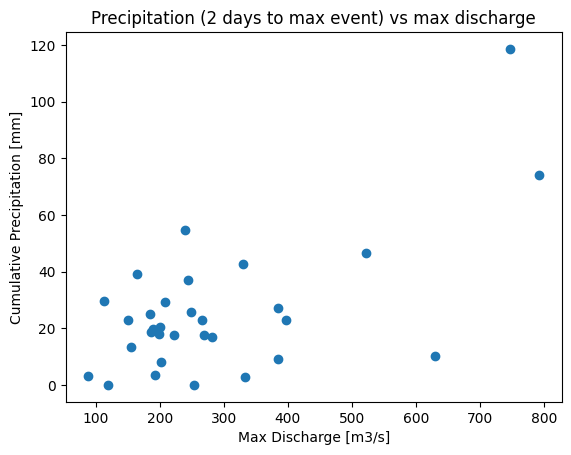

In [16]:
plt.scatter(max_list['Q(m3/s)'], precip2d)
plt.title('Precipitation (2 days to max event) vs max discharge')
plt.xlabel('Max Discharge [m3/s]')
plt.ylabel('Cumulative Precipitation [mm]')

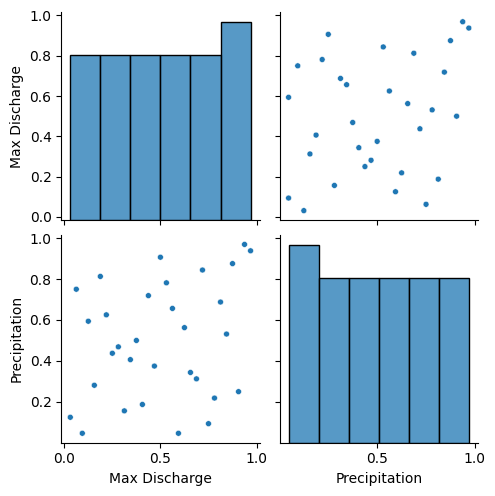

In [17]:
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Precipitation': precip2d}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

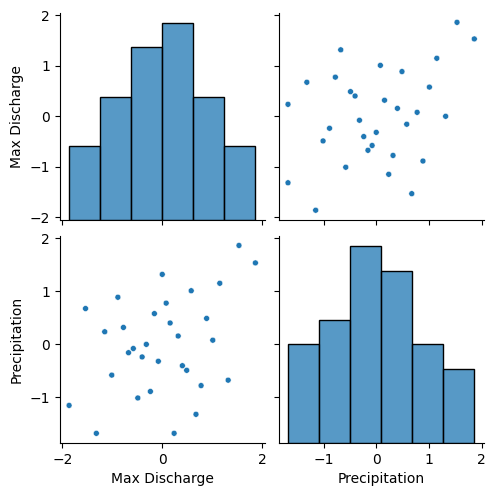

In [18]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()


In [19]:
#plan voor temperatuur: tellen van aantal dagen voor extreem event met temp boven bepaalde drempel (0 graden) 

temp_count = np.zeros(len(max_list))

for i, date in enumerate(max_list.index):
    date_0 = pd.Timestamp(year=date.year, month=1, day=1)
    temp_count[i] = np.sum(df['Tmean [C]'].loc[date_0:date] > 0)
print(temp_count)

rho_temp = stats.pearsonr(max_list['Q(m3/s)'], temp_count)
print('The correlation coefficient for number of days with temperature above 0C is:', rho_temp[0])

spearman_temp = stats.spearmanr(max_list['Q(m3/s)'], temp_count)
print('The spearman correlation coefficient for number of days with temperature above 0C is:', spearman_temp[0])

rho_temp_snow = stats.pearsonr(temp_count, list(winter_snowpack_3month.values()))
print('The correlation coefficient between number of days with temperature above 0C and winter snowpack is:', rho_temp_snow[0])
spearman_temp_snow = stats.spearmanr(temp_count, list(winter_snowpack_3month.values()))
print('The spearman correlation coefficient between number of days with temperature above 0C and winter snowpack is:', spearman_temp_snow[0])
print('Strongest correlation is for days above zero mean temp and winter snowpack with spearman rho =', spearman_temp_snow[0], 'and pearson rho =', rho_temp_snow[0])

[ 83.  52.  24. 116.  65.  68.  64.  30. 110. 174.   6.  35.  76.  37.
  95. 148.  57. 141.  20.  31.  51.  53.  48.  19.  33.  48.   0.  67.
  97.  37. 161.]
The correlation coefficient for number of days with temperature above 0C is: 0.054769650869759184
The spearman correlation coefficient for number of days with temperature above 0C is: -0.14781206188816584
The correlation coefficient between number of days with temperature above 0C and winter snowpack is: -0.14862422902644395
The spearman correlation coefficient between number of days with temperature above 0C and winter snowpack is: -0.23593466904386634
Strongest correlation is for days above zero mean temp and winter snowpack with spearman rho = -0.23593466904386634 and pearson rho = -0.14862422902644395


In [20]:
temp_mean = np.zeros(len(max_list))
for i, date in enumerate(max_list.index):
    date_0 = pd.Timestamp(year=date.year, month=1, day=1)
    temp_mean[i] = np.mean(df['Tmean [C]'].loc[date_0:date])
print(temp_mean)

rho_temp = stats.pearsonr(max_list['Q(m3/s)'], temp_mean)
print('The correlation coefficient for mean temperature is:', rho_temp[0])

spearman_temp = stats.spearmanr(max_list['Q(m3/s)'], temp_mean)
print('The spearman correlation coefficient for mean temperature is:', spearman_temp[0])

rho_temp_snow = stats.pearsonr(temp_mean, list(winter_snowpack_3month.values()))
print('The correlation coefficient between mean temperature and winter snowpack is:', rho_temp_snow[0])
spearman_temp_snow = stats.spearmanr(temp_mean, list(winter_snowpack_3month.values()))
print('The spearman correlation coefficient between mean temperature and winter snowpack is:', spearman_temp_snow[0])   


[ -1.86256022  -4.91567205  -5.43657917  -1.10858927  -2.8804529
  -2.90235177  -3.16603707  -4.3097599    0.68865495  -0.06780784
  -6.4152997   -4.7197574   -1.71516928  -3.79850398  -0.92268988
  -0.58688097  -3.23230447  -1.44595993  -7.7099297   -4.25036776
  -2.89847524  -3.95145254  -3.35304518  -7.94676828  -4.61899775
  -2.3977778  -14.92137626  -2.04731489  -0.98713427  -4.4906443
   1.57143395]
The correlation coefficient for mean temperature is: 0.09859036303985629
The spearman correlation coefficient for mean temperature is: -0.0814516129032258
The correlation coefficient between mean temperature and winter snowpack is: -0.1083896486660659
The spearman correlation coefficient between mean temperature and winter snowpack is: -0.09193548387096774


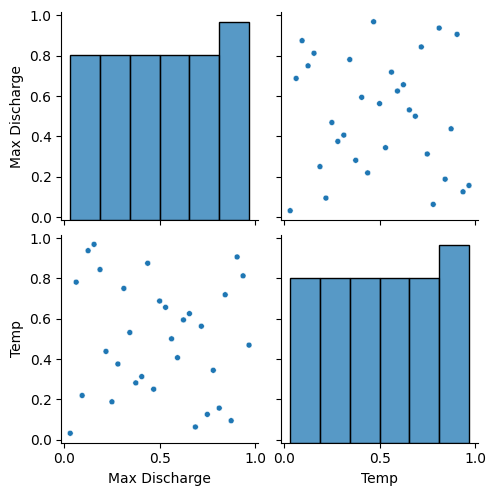

In [21]:
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Temp': temp_mean}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

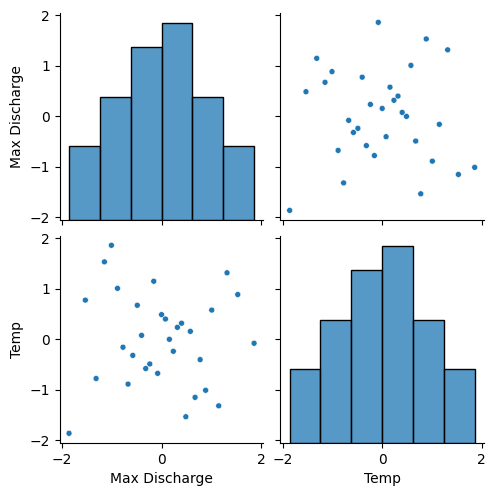

In [22]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [23]:
data = pd.DataFrame({'days above zero temp': temp_count, 'Precipitation 2 days': precip2d, 'snowpack winter months': list(winter_snowpack_3month.values()), 'Max Discharge': max_list['Q(m3/s)']})
display(data)

,days above zero temp,Precipitation 2 days,snowpack winter months,Max Discharge
date,,,,
1993-07-13,83.0,54.667362,13.035959,239.157100
1994-06-30,52.0,18.541507,8.108350,185.712500
1995-06-02,24.0,27.164099,10.626453,383.985200
1996-08-28,116.0,29.583591,6.413787,113.080000
1997-07-03,65.0,22.975514,9.724399,265.306300
1998-06-29,68.0,17.915976,4.779759,199.251500
1999-06-29,64.0,25.664130,8.308645,248.661300
2000-05-18,30.0,8.173420,11.143735,202.076233
2003-08-16,110.0,23.063913,10.500377,150.487863


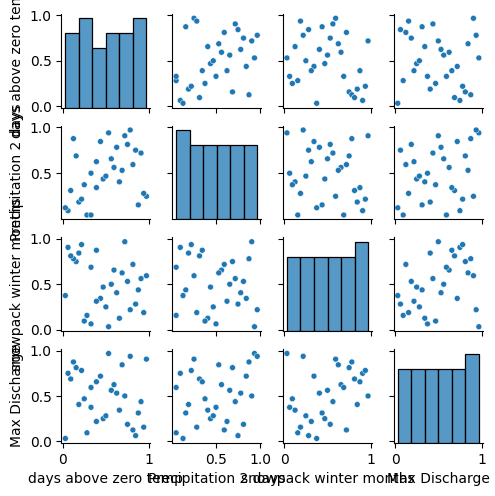

In [24]:
def unity(data):
    u_hat = data.copy()
    for col in data.columns:
        u_hat[col] = stats.rankdata(data[col]) / (len(data)+1)
    return u_hat

unity_data = unity(data)
sns.pairplot(unity_data, height=1.25, plot_kws=dict(size=.1))
plt.show()

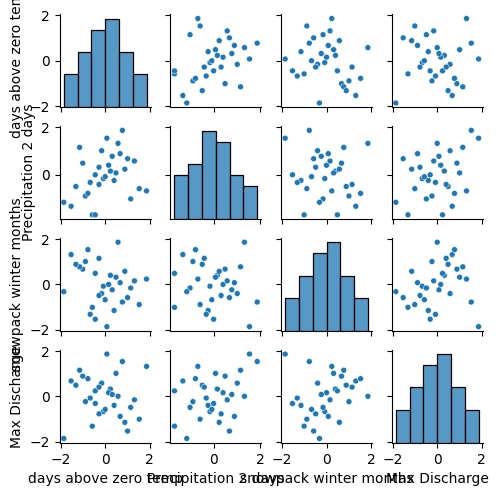

In [25]:
def sd_normal(data):
    sd_data = stats.norm.ppf(data)
    return sd_data

sd_data = pd.DataFrame(sd_normal(unity_data), columns = data.columns)
sns.pairplot(sd_data, height=1.25,plot_kws=dict(size=.1))
plt.show()

In [26]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = data, names = data.columns, fig_name='cvm')#your code here. Use Banshee!
print(M)

                     Var1                    Var2         r   Clayton  \
0    days above zero temp    Precipitation 2 days  0.334678  0.016869   
1    days above zero temp  snowpack winter months -0.235935  0.015196   
2    days above zero temp           Max Discharge -0.147812  0.022327   
3    Precipitation 2 days  snowpack winter months -0.135296  0.011884   
4    Precipitation 2 days           Max Discharge  0.254461  0.027368   
5  snowpack winter months           Max Discharge   0.32621  0.036984   

      Frank  Gaussian    Gumbel  
0   0.02282  0.036145  0.040909  
1  0.037674  0.031073  0.033777  
2  0.018546  0.017074  0.019933  
3  0.025649  0.021869   0.01231  
4  0.024953  0.022268  0.021765  
5  0.020466  0.045373   0.03205  


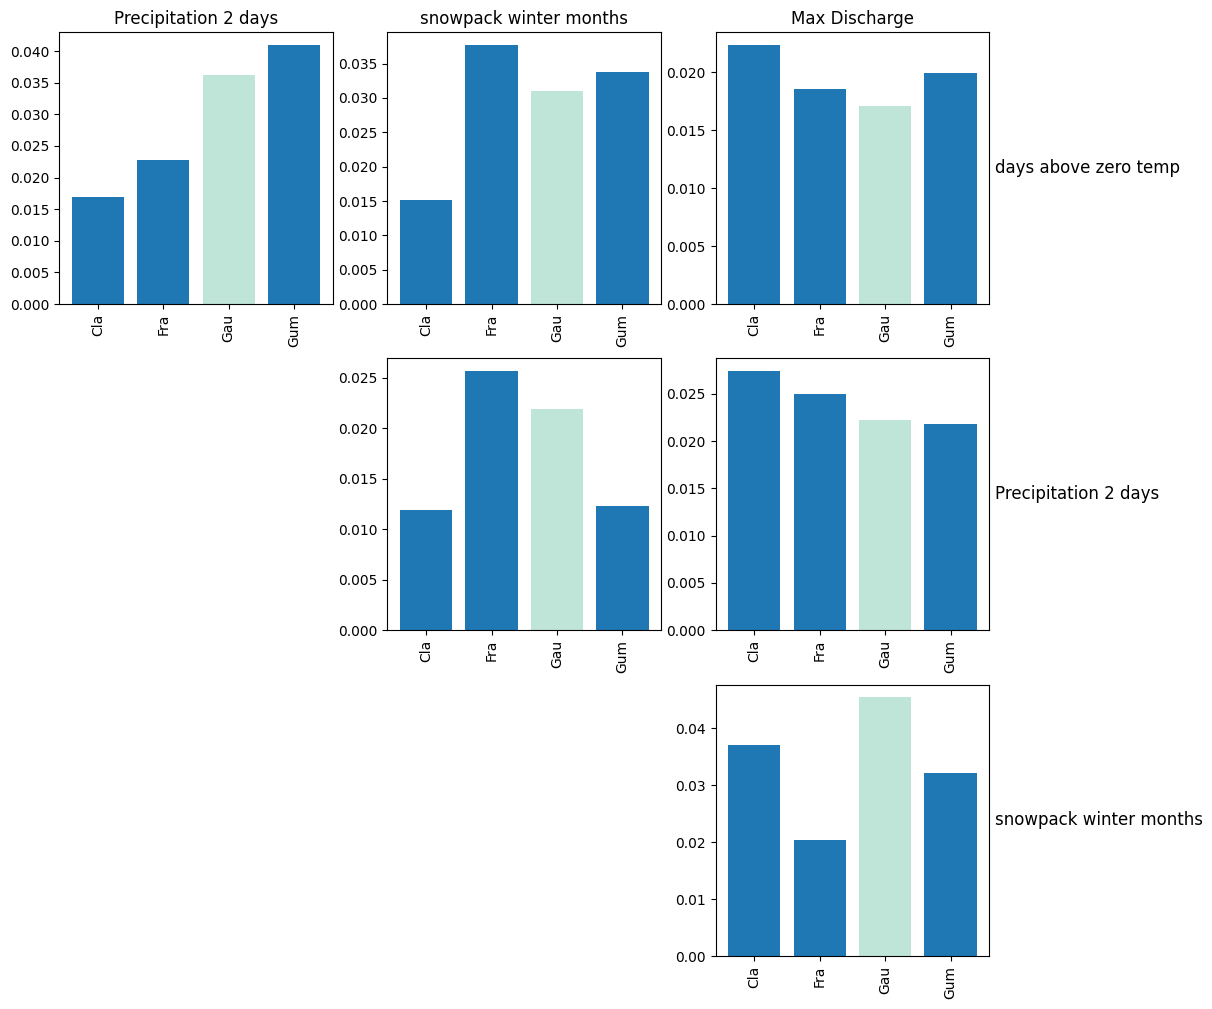

In [27]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(DATA = data, plot = 1, names = data.columns, fig_name='cvm')
plt.show()

In [28]:
print(M)

                     Var1                    Var2         r   Clayton  \
0    days above zero temp    Precipitation 2 days  0.334678  0.016869   
1    days above zero temp  snowpack winter months -0.235935  0.015196   
2    days above zero temp           Max Discharge -0.147812  0.022327   
3    Precipitation 2 days  snowpack winter months -0.135296  0.011884   
4    Precipitation 2 days           Max Discharge  0.254461  0.027368   
5  snowpack winter months           Max Discharge   0.32621  0.036984   

      Frank  Gaussian    Gumbel  
0   0.02282  0.036145  0.040909  
1  0.037674  0.031073  0.033777  
2  0.018546  0.017074  0.019933  
3  0.025649  0.021869   0.01231  
4  0.024953  0.022268  0.021765  
5  0.020466  0.045373   0.03205  


Create model using dissman from values

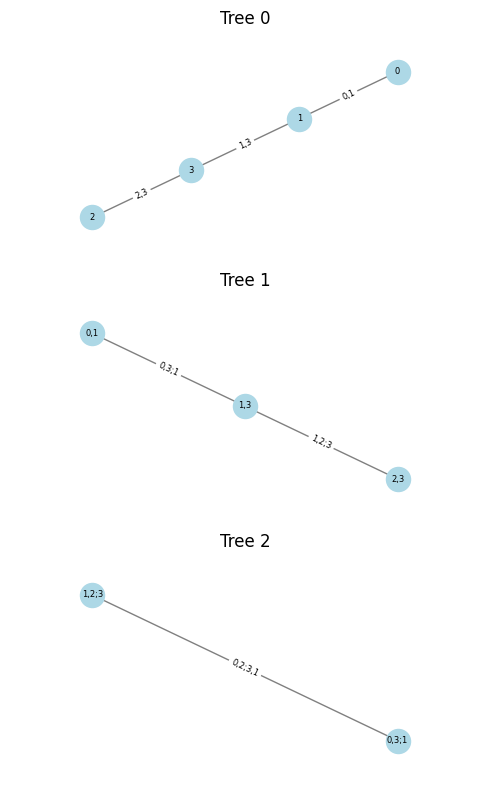

In [29]:
vine_model = pv.Vinecop.from_data(unity_data.values)

vine_model.plot(layout='spring_layout')



In [30]:
print(vine_model)

<pyvinecopulib.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types       family rotation       parameters  df   tau 
   1    1                  1, 2                             c, c      Clayton        0             0.74 1.0  0.27 
   1    2                  2, 4                             c, c          Joe        0             1.66 1.0  0.27 
   1    3                  3, 4                             c, c        Frank        0             2.24 1.0  0.24 
   2    1                  1, 4                      2      c, c         Tawn       90 0.30, 0.66, 7.00 3.0 -0.25 
   2    2                  2, 3                      4      c, c Independence                                0.00 
   3    1                  1, 3                   4, 2      c, c Independence                                0.00 



model using brute force

In [31]:
controls = pv.FitControlsVinecop(preselect_families=False)
# controls = pv.FitControlsBicop()

[<get_matrices.matrix object at 0x000002461EC3ABA0>, <get_matrices.matrix object at 0x000002461EFBF4D0>, <get_matrices.matrix object at 0x000002461EFBF750>, <get_matrices.matrix object at 0x000002461ED21CD0>, <get_matrices.matrix object at 0x000002461ED22060>, <get_matrices.matrix object at 0x000002461511B1D0>, <get_matrices.matrix object at 0x0000024615214160>, <get_matrices.matrix object at 0x000002461ECA28B0>, <get_matrices.matrix object at 0x000002461528CD50>, <get_matrices.matrix object at 0x000002461528FD50>, <get_matrices.matrix object at 0x00000246151699A0>, <get_matrices.matrix object at 0x000002461EC91130>, <get_matrices.matrix object at 0x000002461EF149F0>, <get_matrices.matrix object at 0x000002461EFB6C10>, <get_matrices.matrix object at 0x000002461F184A10>, <get_matrices.matrix object at 0x000002461EF3B650>, <get_matrices.matrix object at 0x000002461EF3BC50>, <get_matrices.matrix object at 0x000002461ED13C20>, <get_matrices.matrix object at 0x000002461ED13E30>, <get_matric

array([[2, 4, 4, 4],
       [4, 1, 1, 0],
       [1, 2, 0, 0],
       [3, 0, 0, 0]], dtype=uint64)

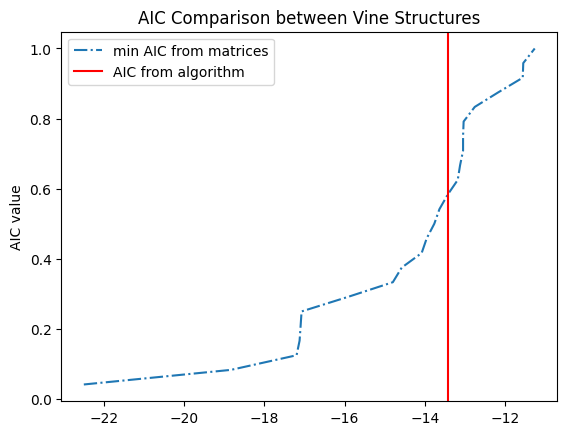

In [32]:
matrices_4_nodes = get_matrices('./CHIMERA_5/', nodes=4)
print(matrices_4_nodes)

#Define a dictionary to store all the models
myDictionary = {} 

#Fit all the models
# for i, matrix_object in enumerate(matrices_4_nodes):
#     structure = pv.RVineStructure.from_matrix(matrix_object.matrix)
#     vc = pv.Vinecop.from_structure(structure)
#     vc.select(unity_data.values, controls=controls)
#     myDictionary[i] = vc

for i in range(len(matrices_4_nodes)):
    myDictionary.update({str(i): pv.Vinecop.from_data(np.array(unity_data), matrix=matrices_4_nodes[i].matrix)})

vines_AIC = []
for keys in myDictionary:
    vines_AIC.append(myDictionary[keys].aic())

print(vines_AIC)
vine_min_aic_index = np.argmin(vines_AIC)
aic_ecdf = mf.ecdf(vines_AIC)
algo_aic = vine_model.aic()

plt.plot(aic_ecdf[0], aic_ecdf[1], label='min AIC from matrices', linestyle='-.')
plt.axvline(x=algo_aic, color='r', linestyle='-', label='AIC from algorithm')
plt.ylabel('AIC value')
plt.title('AIC Comparison between Vine Structures')
plt.legend()
plt.savefig('..//Figures//AIC_comparison.png', dpi=300)

min_aic_index = vines_AIC.index(min(vines_AIC))
vine_min_aic = myDictionary[list(myDictionary.keys())[min_aic_index]] #regular vine with the lowest AIC
vine_min_aic.matrix


<pyvinecopulib.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types       family rotation       parameters  df   tau 
   1    1                  3, 2                             c, c Independence                                0.00 
   1    2                  2, 4                             c, c          Joe        0             1.66 1.0  0.27 
   1    3                  1, 4                             c, c      Student        0      -0.25, 2.00 2.0 -0.16 
   2    1                  3, 4                      2      c, c         Tawn        0 0.50, 0.47, 6.04 3.0  0.30 
   2    2                  2, 1                      4      c, c         Tawn      180 0.33, 1.00, 4.03 3.0  0.29 
   3    1                  3, 1                   4, 2      c, c Independence                                0.00 



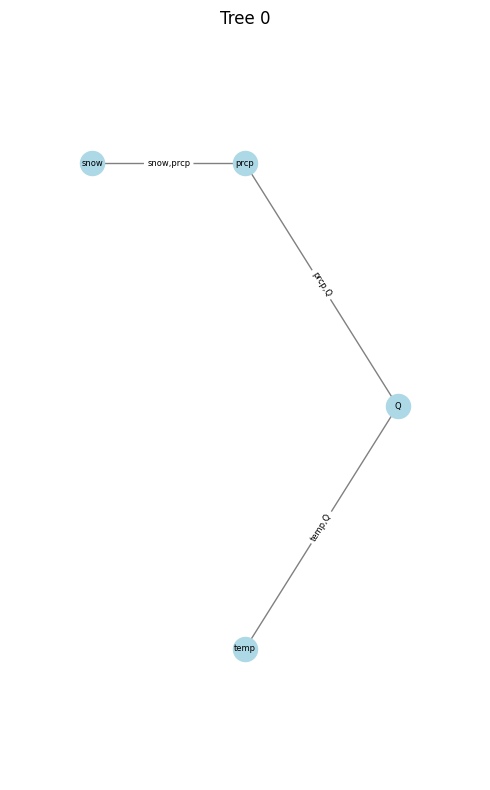

In [33]:
print(vine_min_aic)
vine_min_aic.plot(layout='graphviz', tree=[0], vars_names=['temp', 'prcp', 'snow', 'Q'])
# plt.savefig('..//Figures//Vine_min_AIC.png', dpi=300)


Sampling

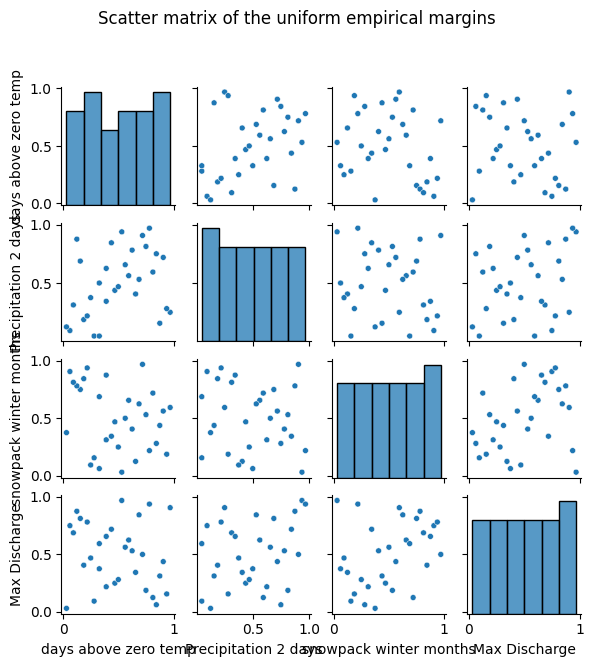

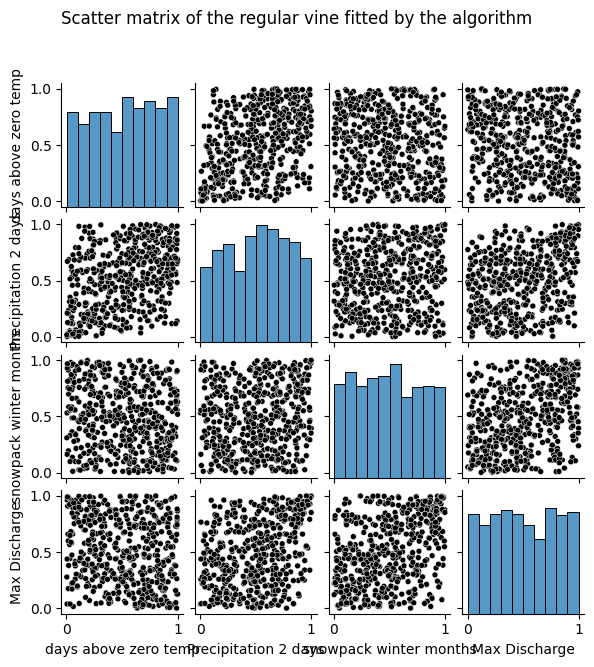

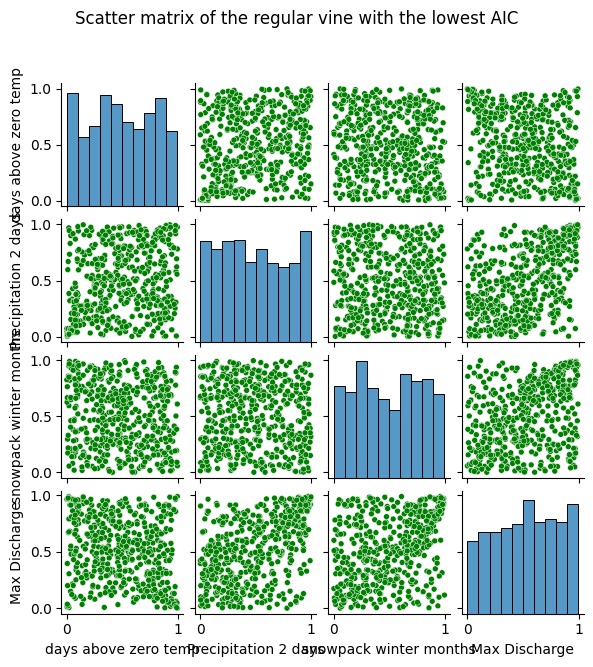

In [34]:
# Draw samples from Brute Force model
number_of_samples = 500
uv_samples_vine_min = vine_min_aic.simulate(number_of_samples)
uvs_min_aic = pd.DataFrame(data=uv_samples_vine_min, columns=data.columns)

# Draw samples from the vine model fitted by the algorithm
uv_samples = vine_model.simulate(number_of_samples)
uvs = pd.DataFrame(data=uv_samples, columns=data.columns)

sp = sns.pairplot(unity_data, height=1.5,plot_kws=dict(size=.1))
sp.fig.suptitle('Scatter matrix of the uniform empirical margins',y=1.1)
plt.savefig('..\\Figures\\vinemodel\\scatter_empirical_margins.png')

sp2 = sns.pairplot(uvs, height=1.5,plot_kws=dict(color='k', size=.1))
sp2.fig.suptitle('Scatter matrix of the regular vine fitted by the algorithm',y=1.1)
plt.savefig('..\\Figures\\vinemodel\\scatter_vine_algorithm.png')

sp3 = sns.pairplot(uvs_min_aic, height=1.5,plot_kws=dict(color='green', size=.2))
sp3.fig.suptitle('Scatter matrix of the regular vine with the lowest AIC',y=1.1)
plt.savefig('..\\Figures\\vinemodel\\scatter_vine_lowest_AIC.png')

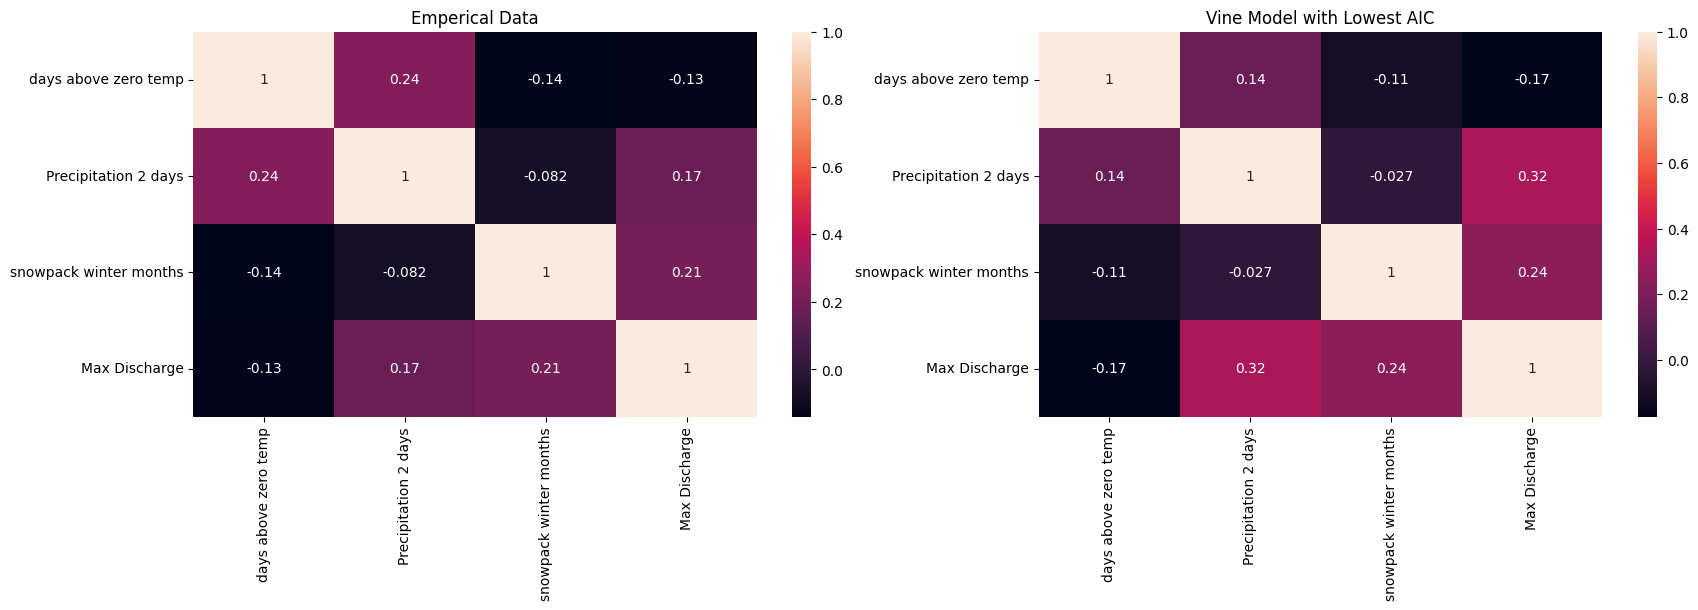

In [58]:
fig, axes = plt.subplots(1,2, figsize=(20,5))
sns.heatmap(unity_data.corr(method = 'kendall'), annot=True, ax=axes[0])
axes[0].set_title('Emperical Data')
# sns.heatmap(uvs.corr(method = 'kendall'), annot=True, ax=axes[1])
sns.heatmap(uvs_min_aic.corr(method = 'kendall'), annot=True, ax=axes[1])
axes[1].set_title('Vine Model with Lowest AIC')
plt.savefig('..\\Figures\\kendall_correlation_matrices.png', bbox_inches='tight', dpi=300)

transforming to variable space

,days above zero temp,Precipitation 2 days,snowpack winter months,Max Discharge,source
0,0.005360,0.000575,0.530593,0.037615,0
1,0.944652,0.639406,0.289834,0.340836,0
2,0.761329,0.224607,0.119128,0.122200,0
3,0.673842,0.698228,0.879264,0.858275,0
4,0.847755,0.511703,0.411693,0.040528,0
...,...,...,...,...,...
526,0.031250,0.125000,0.375000,0.031250,1
527,0.625000,0.781250,0.406250,0.531250,1
528,0.781250,0.968750,0.218750,0.937500,1
529,0.328125,0.500000,0.062500,0.375000,1


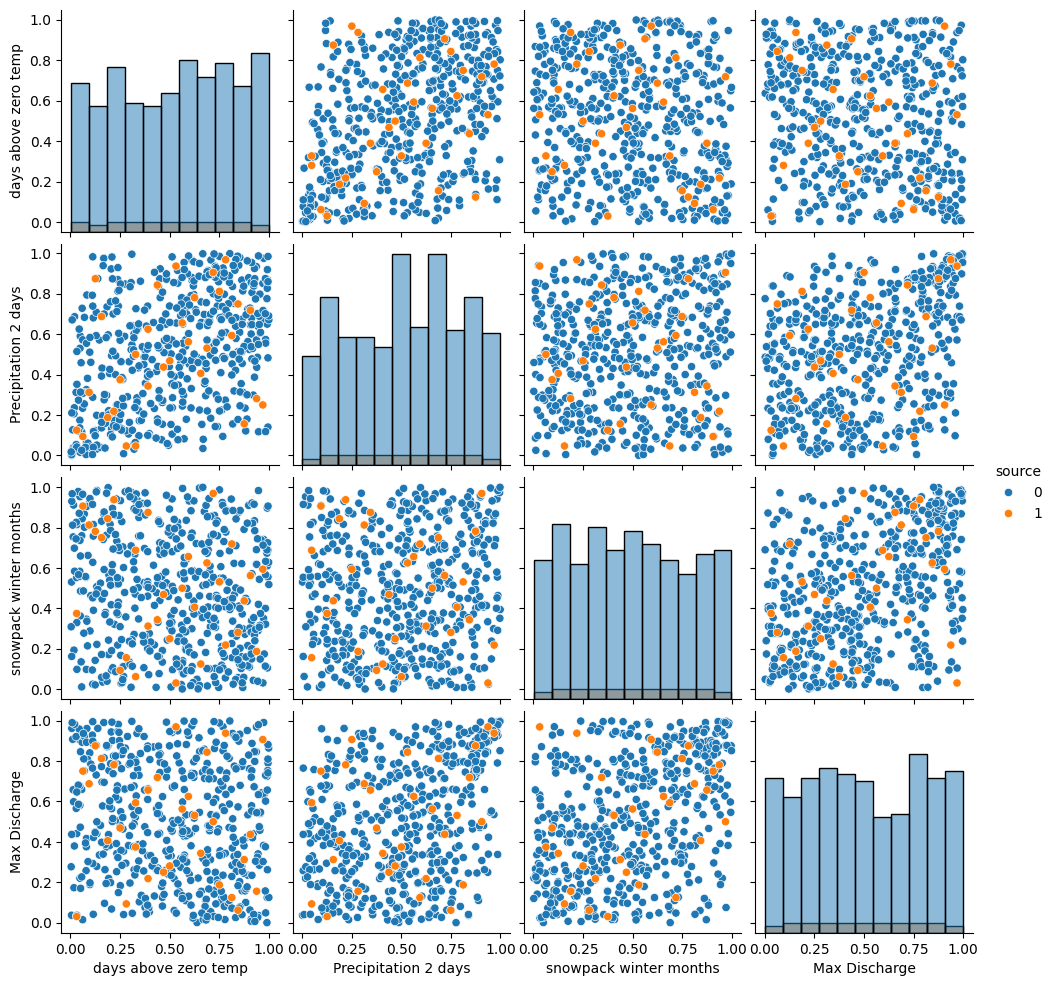

In [36]:
data_unity = unity_data.copy()
data_unity['source'] = 1
samples_unity = pd.DataFrame(uvs, columns=unity_data.columns)
samples_unity['source'] = 0
data_unity['source'] = 1
concat = pd.concat([samples_unity, data_unity], ignore_index=True)
display(concat)

g = sns.pairplot(concat, hue="source", diag_kind="hist")

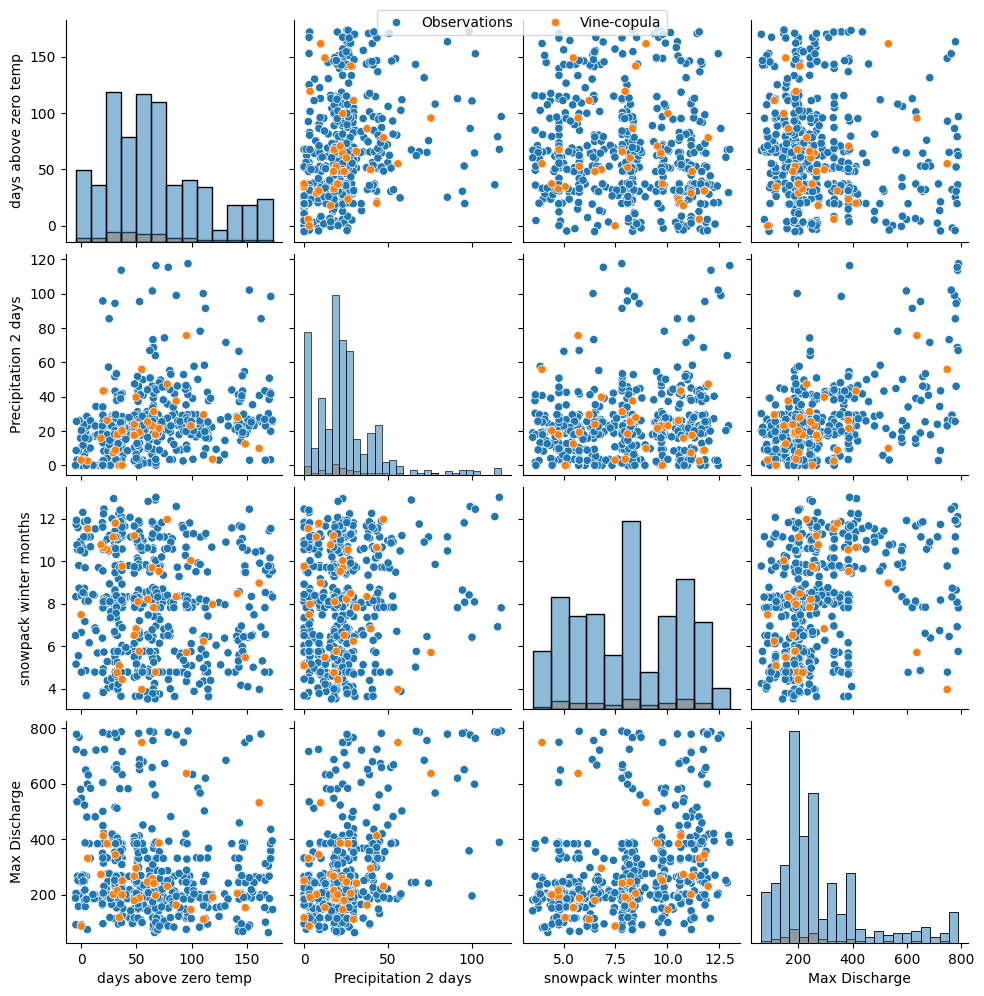

In [37]:
rv_together = [mf.eval_inverse_ecdf(data.iloc[:, col], concat.iloc[:, col]) for col in range(len(concat.columns)-1)]
rv_together=pd.DataFrame(np.transpose(rv_together))
rv_together['source']=concat['source']
rv_together.columns = concat.columns
g = sns.pairplot(data = pd.DataFrame(rv_together), hue="source", diag_kind="hist")
g._legend.set_title(None)
new_labels = ['Observations', 'Vine-copula']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

sns.move_legend(g, "upper center" ,ncol=2, frameon=True, bbox_to_anchor = (0.5,1))
plt.savefig('..\\Figures\\pairplot_vine_vs_data.png', dpi=300)

using model (conditionalizing)

In [38]:
display(data.head())

,days above zero temp,Precipitation 2 days,snowpack winter months,Max Discharge
date,,,,
1993-07-13,83.0,54.667362,13.035959,239.1571
1994-06-30,52.0,18.541507,8.108350,185.7125
1995-06-02,24.0,27.164099,10.626453,383.9852
1996-08-28,116.0,29.583591,6.413787,113.0800
1997-07-03,65.0,22.975514,9.724399,265.3063


In [39]:
# 

# plot_conditionalize(data, vine_min_aic, [0, 1], [80, 100], tol=0.01, n_samples=500000)  

In [40]:
import model_functions as mf
%autoreload 2

Length samples after conditioning: 210


(array([0.00123929, 0.00129889, 0.00212713, 0.0026286 , 0.00216413,
        0.00913743, 0.00199355, 0.00488521, 0.00363154, 0.00067616,
        0.00063917, 0.00196477, 0.00063711, 0.00285879, 0.00025896,
        0.00027334, 0.00030623, 0.00024868, 0.00029184, 0.00028978,
        0.00030828, 0.000298  , 0.00034527, 0.00026307, 0.00023635,
        0.00022402, 0.00028362, 0.00023224, 0.00061656, 0.00074604]),
 array([ 62.68139246,  87.00990822, 111.33842397, 135.66693973,
        159.99545548, 184.32397124, 208.65248699, 232.98100275,
        257.30951851, 281.63803426, 305.96655002, 330.29506577,
        354.62358153, 378.95209728, 403.28061304, 427.60912879,
        451.93764455, 476.2661603 , 500.59467606, 524.92319182,
        549.25170757, 573.58022333, 597.90873908, 622.23725484,
        646.56577059, 670.89428635, 695.2228021 , 719.55131786,
        743.87983362, 768.20834937, 792.53686513]),
 <BarContainer object of 30 artists>)

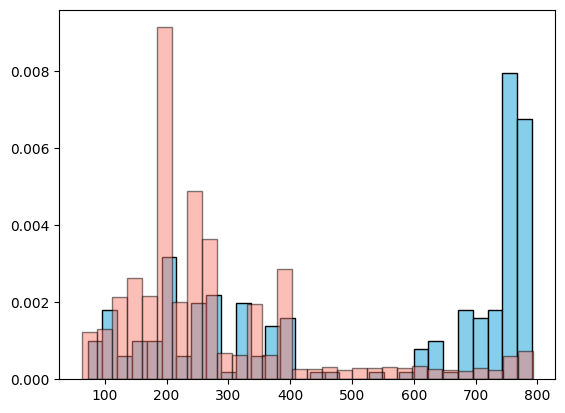

In [64]:
samples_noncond = vine_min_aic.simulate(20000)[:,3]
samples_noncond = [mf.eval_inverse_ecdf(data.iloc[:, 3], samples_noncond)]
samples_cond = mf.conditionalize(data, vine_min_aic, [2], [13], tol=0.01, n_samples=20000)[2]
plt.hist(samples_cond, bins=30, color='skyblue', edgecolor='black', density=True)
plt.hist(samples_noncond, bins=30, color='salmon', edgecolor='black', alpha=0.5, density=True)

In [42]:
result = data.copy()
result['simulated mean'] = 0
result['simulated std'] = 0
result['simulated 5%'] = 0
result['simulated 95%'] = 0
result.index = data.index.year

# for year in result.index:
#     results = pd.DataFrame([[0]], columns=['Max Discharge'])
#     results.to_csv(f"samples/samples_{year}.csv")

## Takes a long time to run!

In [43]:
# years = [2006, 2008]
years = result.index
for year in years:
    print(f"Processing year: {year}\n")
    temp = result.loc[year, "days above zero temp"]
    prcp = result.loc[year, "Precipitation 2 days"]
    snow = result.loc[year, "snowpack winter months"]
    results = mf.conditionalize(data, vine_min_aic, [0, 1, 2], [temp, prcp, snow], tol=0.01, n_samples=1)
    results = pd.DataFrame(results.T, columns=['Max Discharge'])
    results_old = pd.read_csv(f"samples/samples_{year}.csv", usecols=['Max Discharge'])
    results = pd.concat([results_old, results], ignore_index=True)
    results.to_csv(f"samples/samples_{year}.csv")
    results.dropna(inplace=True)
    results = results[results['Max Discharge'] > 0]
    if len(results) > 3 and results.shape[1] == 1:
        result.loc[year, 'simulated mean'] = np.mean(results)
        result.loc[year, 'simulated std'] = results[results.columns[0]].std()
        result.loc[year, 'simulated 5%'] = results[results.columns[0]].quantile(0.05)
        result.loc[year, 'simulated 95%'] = results[results.columns[0]].quantile(0.95)



Processing year: 1993

Length samples after conditioning: 0
Length samples after conditioning: 0
Length samples after conditioning: 0
No samples found for the given conditioning values and tolerance.
Processing year: 1994

Length samples after conditioning: 0
Length samples after conditioning: 0
Length samples after conditioning: 0
No samples found for the given conditioning values and tolerance.
Processing year: 1995

Length samples after conditioning: 0
Length samples after conditioning: 0
Length samples after conditioning: 0
No samples found for the given conditioning values and tolerance.
Processing year: 1996

Length samples after conditioning: 0
Length samples after conditioning: 0
Length samples after conditioning: 0
No samples found for the given conditioning values and tolerance.
Processing year: 1997

Length samples after conditioning: 0
Length samples after conditioning: 0
Length samples after conditioning: 0
No samples found for the given conditioning values and tolerance.


In [44]:
result = result.round(2)
result.to_latex('simulated_discharge_table.tex')
display(result)

,days above zero temp,Precipitation 2 days,snowpack winter months,Max Discharge,simulated mean,simulated std,simulated 5%,simulated 95%
date,,,,,,,,
1993,83.0,54.67,13.04,239.16,490.06,212.01,238.53,783.28
1994,52.0,18.54,8.11,185.71,201.48,59.42,113.54,277.36
1995,24.0,27.16,10.63,383.99,373.00,48.20,329.06,468.30
1996,116.0,29.58,6.41,113.08,201.59,85.55,91.85,368.22
1997,65.0,22.98,9.72,265.31,242.88,59.32,171.38,354.83
1998,68.0,17.92,4.78,199.25,187.47,89.21,104.80,305.16
1999,64.0,25.66,8.31,248.66,226.45,52.44,149.73,292.35
2000,30.0,8.17,11.14,202.08,243.84,85.20,119.96,342.23
2003,110.0,23.06,10.50,150.49,246.78,122.05,109.12,400.00


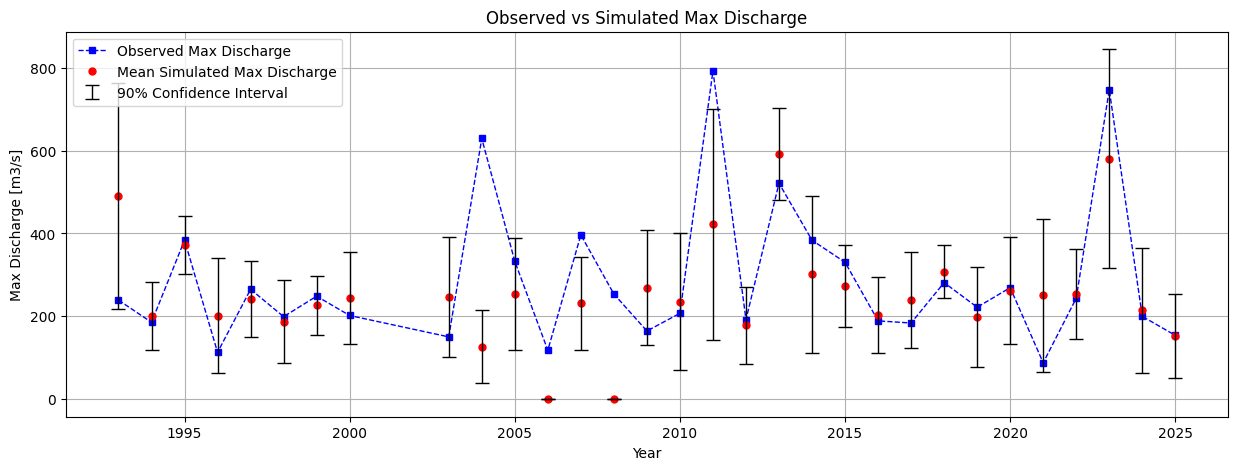

In [45]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(result.index, result['Max Discharge'], ls='--', marker='s', label='Observed Max Discharge', markersize=5, color = 'blue', linewidth=1)
ax.plot(result.index, result['simulated mean'], ls='none', marker='o', color='red', label='Mean Simulated Max Discharge', markersize=5)

error = result["simulated 95%"] - result["simulated 5%"]
ax.errorbar(result.index, result['simulated mean'], yerr=error/2, fmt='none', ecolor='black', capsize=5, label='90% Confidence Interval', linewidth=1)
# ax.fill_between(result.index, result['simulated 5%'], result['simulated 95%'], color='gray', alpha=0.3, label='90% Confidence Interval')
ax.set_xlabel('Year')
ax.grid()
ax.legend()

ax.set_ylabel('Max Discharge [m3/s]')
ax.set_title('Observed vs Simulated Max Discharge')

plt.savefig('..\\Figures\\observed_vs_simulated_max_discharge.png', dpi=300)

In [46]:
table = result.copy()
table.drop(columns=['simulated std', 'simulated 5%', 'simulated 95%', 'simulated mean'], inplace=True)
table.to_latex('observed_max_discharge_table.tex', float_format="%.2f")

In [51]:
# result analysis
n_results_std = 0
n_results_cin = 0
n_total_obser = len(result.index)

for year in result.index:
    std = result.loc[year, 'simulated std'] 
    obs = result.loc[year, 'Max Discharge']
    p05 = result.loc[year, 'simulated 5%']
    p95 = result.loc[year, 'simulated 95%']
    avg = result.loc[year, 'simulated mean']

    if np.abs(obs - avg) <= std:
        # print(f"Year {year}: Observation within 1 std dev")
        n_results_std += 1

    if p05 <= obs <= p95:
        # print(f"Year {year}: Observation within 90% confidence interval")
        n_results_cin += 1

print(f"Proportion of observations within 1 std dev: {n_results_std}/{n_total_obser} = {n_results_std/n_total_obser:.2f}")
print(f"Proportion of observations within 90% confidence interval: {n_results_cin}/{n_total_obser} = {n_results_cin/n_total_obser:.2f}")

#RMSE calculation
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(result['Max Discharge'], result['simulated mean'])
print(f"RMSE between observed and simulated mean max discharge: {rmse:.2f} m3/s")

Proportion of observations within 1 std dev: 23/31 = 0.74
Proportion of observations within 90% confidence interval: 26/31 = 0.84
RMSE between observed and simulated mean max discharge: 21655.58 m3/s
